# Nemotron-Personas-Korea — Notebook 03: Values-Based Psychographic Clustering

**연구 질문**: LLM이 생성한 합성 한국어 페르소나 데이터에서, 인구통계 변수 없이 **가치관·지향 텍스트**만으로 의미 있는 사이코그래픽 군집을 추출할 수 있는가?

**핵심 설계**: 행동 텍스트가 아닌 가치관·정체성 텍스트(`persona`, `cultural_background`, `career_goals_and_ambitions`)를 군집화 입력으로 사용하고, 행동 텍스트는 비교 레이어로만 활용한다.

| 레이어 | 컬럼 | 역할 |
|--------|------|------|
| Layer A | persona, cultural_background, career_goals_and_ambitions | 군집화 핵심 입력 |
| Layer B | hobbies_and_interests, sports_persona, arts_persona, travel_persona, culinary_persona | 비교용 |
| 인구통계 | age_group, sex, province, education_level, occupation | 반전 분석에서만 사용 |

> **Notebook 02와의 차이**: 02는 행동(뭘 하는가)으로 군집화 → 03은 가치관(왜 하는가)으로 군집화.  
> 섹션 8에서 두 군집의 교차 구조를 비교해 가치관·행동이 독립적 레이어인지 확인한다.

---
## 섹션 1. 데이터 로드 & 텍스트 확인

Layer A 컬럼 세 개가 가치관 군집화의 전부다. 여기서 텍스트 길이가 충분한지, 내용이 실제로 가치·지향을 담는지 먼저 육안으로 확인한다.

In [1]:
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path='../.env')
from huggingface_hub import login
login(token=os.environ.get("HF_TOKEN"))

# nemotron_theme — 오방색 × HuggingFace 팔레트
import sys; sys.path.insert(0, '../src')
from nemotron_theme import apply, T, save, fig, color_list
from nemotron_theme import cluster_scatter, metric_plot, bar_keywords, radar, heatmap_style
from nemotron_theme import (
    CMAP_HEATMAP, CMAP_DIVERGING, CMAP_SEQUENTIAL,
    sankey_node_colors, color_list
)
apply()
print('nemotron_theme 로드 완료')


nemotron_theme 로드 완료


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform
import os
import warnings
warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../image/nb03', exist_ok=True)

RANDOM_STATE = 42
SAMPLE_PER_GROUP = 1500

LAYER_A_COLS = ['persona', 'cultural_background', 'career_goals_and_ambitions']
LAYER_B_COLS = ['hobbies_and_interests', 'sports_persona', 'arts_persona',
                'travel_persona', 'culinary_persona']
DEMO_COLS = ['age_group', 'sex', 'province', 'education_level', 'occupation']

df = pd.read_parquet('../data/Nemotron-Personas-Korea.parquet')
print(f"전체 행 수: {len(df):,} / 컬럼 수: {len(df.columns)}")

# 연령대 생성
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 30, 40, 50, 60, 70, 80, 100],
    labels=['20대', '30대', '40대', '50대', '60대', '70대', '80대이상']
)

# Layer A 텍스트 길이 분포 확인
print("\n=== Layer A 텍스트 길이 확인 ===")
for col in LAYER_A_COLS:
    avg = df[col].str.len().mean()
    mn = df[col].str.len().min()
    mx = df[col].str.len().max()
    print(f"  {col}: 평균 {avg:.0f}자 / 최소 {mn}자 / 최대 {mx}자")

print("\n=== Layer B 텍스트 길이 확인 ===")
for col in LAYER_B_COLS:
    avg = df[col].str.len().mean()
    print(f"  {col}: 평균 {avg:.0f}자")

전체 행 수: 1,000,000 / 컬럼 수: 28

=== Layer A 텍스트 길이 확인 ===
  persona: 평균 81자 / 최소 42자 / 최대 174자
  cultural_background: 평균 135자 / 최소 55자 / 최대 299자
  career_goals_and_ambitions: 평균 118자 / 최소 47자 / 최대 243자

=== Layer B 텍스트 길이 확인 ===
  hobbies_and_interests: 평균 129자
  sports_persona: 평균 134자
  arts_persona: 평균 138자
  travel_persona: 평균 135자
  culinary_persona: 평균 142자


In [3]:
# Layer A 원문 샘플 3개 육안 확인
print("=" * 65)
for i, row in df.sample(3, random_state=RANDOM_STATE).iterrows():
    print(f"\n[persona]         {row['persona']}")
    print(f"[cultural]        {row['cultural_background'][:100]}...")
    print(f"[goals]           {row['career_goals_and_ambitions']}")
    print(f"[인구통계]         {int(row['age'])}세 {row['sex']} / {row['province']} / {row['education_level']}")
    print("-" * 65)


[persona]         주정숙 씨는 여수의 바닷바람과 고단한 삶의 세월을 견디며 자녀들을 키워낸, 강인함과 부드러움을 동시에 지닌 60대 보안원입니다.
[cultural]        여수 앞바다의 짠 내와 함께 나이 들었고, 중학교 졸업 후 곧바로 생업에 뛰어들어 자식들을 키워낸 세월이 몸에 배어 있습니다. 남편과는 떨어져 지내지만, 다세대 주택의 좁은 복도에...
[goals]           직급 상승이나 큰 성취보다는 지금처럼 건강하게 출근하며, 매달 들어오는 월급으로 자녀들에게 소소한 용돈을 챙겨줄 수 있는 평범한 일상의 유지를 바랍니다.
[인구통계]         69세 여자 / 전라남 / 중학교
-----------------------------------------------------------------

[persona]         박예슬 씨는 안양에 거주하며 테마파크 서비스직으로 근무하는 20대 후반 여성으로, 섬세한 고객 응대 능력과 외모 가꾸기, 그리고 모바일 게임이라는 확고한 취향을 가진 성실한 직장인입니다.
[cultural]        안양 만안구의 조용한 주거지에서 성장하며 예의와 성실함을 익혔고, 대학에서 서비스학을 전공하며 타인의 필요를 빠르게 읽어내는 감각을 키웠습니다. 부모님과 함께 거주하며 가족 간의 ...
[goals]           단순한 현장 응대를 넘어 방문객의 전체적인 경험을 설계하는 테마파크 운영 기획자로 성장해, 대기 시간을 줄이는 효율적인 시스템을 도입하고 싶어 합니다. 다만, 업무 강도가 높은 서비스직의 특성상 때때로 찾아오는 심한 체력적 소모와 매너리즘을 극복해야 하는 과제를 안고 있습니다.
[인구통계]         28세 여자 / 경기 / 4년제 대학교
-----------------------------------------------------------------

[persona]         김준희 씨는 남악신도시에서 꼼꼼한 임대 관리로 신뢰받는 사무 보조원이자, 

---
## 섹션 2. 샘플링 & 텍스트 레이어 구성

인구통계 편향을 차단하기 위해 연령대별 균등 샘플링(1,500행 × 7그룹 = 10,500행). 이후 모든 분석은 인구통계를 보지 않는다.

In [4]:
sample_df = pd.concat([
    g.sample(min(SAMPLE_PER_GROUP, len(g)), random_state=RANDOM_STATE)
    for _, g in df.groupby('age_group', observed=True)
]).reset_index(drop=True)

print(f"샘플 크기: {len(sample_df):,}행")
print(sample_df['age_group'].value_counts().sort_index())

# Layer 텍스트 생성
sample_df['layer_a_text'] = sample_df[LAYER_A_COLS].fillna('').agg(' '.join, axis=1)
sample_df['layer_b_text'] = sample_df[LAYER_B_COLS].fillna('').agg(' '.join, axis=1)

print(f"\nLayer A 평균 길이: {sample_df['layer_a_text'].str.len().mean():.0f}자")
print(f"Layer B 평균 길이: {sample_df['layer_b_text'].str.len().mean():.0f}자")

샘플 크기: 10,500행
age_group
20대      1500
30대      1500
40대      1500
50대      1500
60대      1500
70대      1500
80대이상    1500
Name: count, dtype: int64

Layer A 평균 길이: 337자
Layer B 평균 길이: 675자


---
## 섹션 2.5. 형태소 정규화 — 어미 제거 & 원형 복원

한국어는 동일 어근이 어미에 따라 다른 표면형으로 나타난다.  
(`성실하고` / `성실한` / `성실하게` → 모두 `성실하다`로 통일)  
정규화하지 않으면 Sentence Transformer와 TF-IDF 모두 같은 의미를 다른 토큰으로 처리한다.  
kiwipiepy로 품사 분석 → 동사·형용사는 원형(`어간 + 다`)으로, 명사는 그대로 유지.

In [5]:
from kiwipiepy import Kiwi
from tqdm.auto import tqdm

kiwi = Kiwi()

CONTENT_TAGS = {
    'NNG', 'NNP', 'NNB',        # 일반·고유·의존 명사
    'VV', 'VA', 'VX', 'VCP',    # 동사, 형용사, 보조용언, 긍정지정사
    'MAG', 'MAJ',                # 일반·접속 부사
    'XR',                        # 어근
}

def normalize_korean(text: str) -> str:
    """어미 제거 + 원형 복원. 동사/형용사는 어간+'다' 형태로 반환."""
    try:
        tokens = kiwi.tokenize(text, normalize_coda=True)
        result = []
        for t in tokens:
            if t.tag not in CONTENT_TAGS:
                continue
            if len(t.form) < 2:
                continue
            if t.tag in ('VV', 'VA', 'VX', 'VCP'):
                result.append(t.form + '다')   # 어간 + 다 → 원형
            else:
                result.append(t.form)
        return ' '.join(result)
    except Exception:
        return ''

tqdm.pandas()
# Layer A 정규화 (약 5~10분 소요)
print("Layer A 정규화 중...")
sample_df['layer_a_norm'] = sample_df['layer_a_text'].apply(normalize_korean)

# Layer B 정규화
print("Layer B 정규화 중...")
sample_df['layer_b_norm'] = sample_df['layer_b_text'].apply(normalize_korean)

print("완료")
print(f"\nLayer A 정규화 전: {sample_df['layer_a_text'].str.len().mean():.0f}자")
print(f"Layer A 정규화 후: {sample_df['layer_a_norm'].str.len().mean():.0f}자")

normalize_text = normalize_korean  # alias

Layer A 정규화 중...
Layer B 정규화 중...
완료

Layer A 정규화 전: 337자
Layer A 정규화 후: 214자


In [6]:
print("=== 정규화 전후 비교 (3행 샘플) ===")
for _, row in sample_df.sample(3, random_state=42).iterrows():
    print(f"\n[원문  ] {row['layer_a_text'][:120]}")
    print(f"[정규화] {row['layer_a_norm'][:120]}")
    print("-" * 60)

=== 정규화 전후 비교 (3행 샘플) ===

[원문  ] 김수진 씨는 광주 서구의 전셋집에서 반려견과 함께 살며, 십 원 단위의 가계부와 완벽한 수납 정리로 자신의 삶을 통제하며 소박한 안정을 찾는 50대 중반의 여성입니다. 광주 서구에서 오래 거주하며 무등산 자락의 정취
[정규화] 김수진 광주 서구 전셋집 반려견 함께 단위 가계부 완벽 수납 정리 자신 통제 소박 안정 중반 여성 광주 서구 오래 거주 무등산 자락 정취 지역 공동체 정서 익숙 중학교 졸업 일찍이 사회생활 시작 성실 조용 내면 자신
------------------------------------------------------------

[원문  ] 정진헌 씨는 일산의 평온한 일상 속에서 옛 공학도의 정밀함과 노년의 여유를 함께 간직한 채 아내와 함께 걷는 삶을 사는 은퇴자입니다. 대한민국의 급격한 산업 성장기를 온몸으로 겪어낸 공학도로서, 일산신도시의 계획된 
[정규화] 정진 일산 평온 일상 공학도 정밀 노년 여유 함께 간직 아내 함께 은퇴자 대한민국 급격 산업 성장기 온몸 공학도 일산 도시 계획 정온 은퇴 꾸리다 세대 특유 성실 이제 강박 성취 주변 사람 조화 마음 평온 중요 여기
------------------------------------------------------------

[원문  ] 양경덕 씨는 수원 장안구에서 평생 기계 조작원으로 성실하게 살아온, 투박한 손마디에 삶의 지혜와 가족에 대한 사랑이 깃든 74세의 가장입니다. 수원 장안구의 오래된 골목에서 평생을 보내며 글보다는 몸으로 세상을 배웠
[정규화] 수원 장안구 평생 기계 조작 성실 살아오다 투박 손마디 지혜 가족 대하다 사랑 깃들다 가장 수원 장안구 오래 골목 평생 보내다 세상 배우다 산업 시대 거칠다 현장 성실 가정 지키다 세월 갈등 피하다 온순 성품 덕분 
------------------------------------------------------------


> **정규화 효과 확인 포인트**
> - `성실하고` → `성실하다` / `나누며` → `나누다` / `살아가는` → `살아가다` 로 변환되는지 확인
> - 명사(`자립`, `공동체`, `경제`)는 원형 그대로 유지되는지 확인
> - 정규화 후 텍스트 길이가 원문의 50~70% 수준이면 정상 (조사·어미 제거로 단축)
> - 이후 Sentence Transformer와 TF-IDF 모두 `layer_a_norm` / `layer_b_norm` 사용

---
## 섹션 3. 임베딩 — Sentence Transformer

`jhgan/ko-sroberta-multitask`는 한국어 문장 간 의미 유사도에 최적화된 모델이다.
가치관·지향 텍스트는 표층 키워드보다 **문장 전체의 방향성**이 중요하므로 TF-IDF 대신 의미 기반 임베딩을 사용한다.
인코딩 결과는 `.npy`로 저장해 재실행 시 재인코딩 생략한다.

In [7]:
from sentence_transformers import SentenceTransformer

# Load the Korean SentenceTransformer model used in your previous notebooks
model = SentenceTransformer('jhgan/ko-sroberta-multitask')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [8]:
import os
os.makedirs('../data/embeddings', exist_ok=True)
PATH_A = '../data/embeddings/X_a.npy'
PATH_B = '../data/embeddings/X_b.npy'

if os.path.exists(PATH_A) and os.path.exists(PATH_B):
    print("저장된 임베딩 로드 중...")
    X_a = np.load(PATH_A)
    X_b = np.load(PATH_B)
    print(f"X_a: {X_a.shape}, X_b: {X_b.shape}")
else:
    print("임베딩 생성 중 (CPU 기준 20~40분)...")
    X_a = model.encode(
        sample_df['layer_a_norm'].tolist(),
        batch_size=64, show_progress_bar=True,
        normalize_embeddings=True
    )
    X_b = model.encode(
        sample_df['layer_b_text'].tolist(),
        batch_size=64, show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(PATH_A, X_a)
    np.save(PATH_B, X_b)
    print(f"저장 완료 → {PATH_A}, {PATH_B}")
    print(f"X_a: {X_a.shape}, X_b: {X_b.shape}")

저장된 임베딩 로드 중...
X_a: (10500, 768), X_b: (10500, 768)


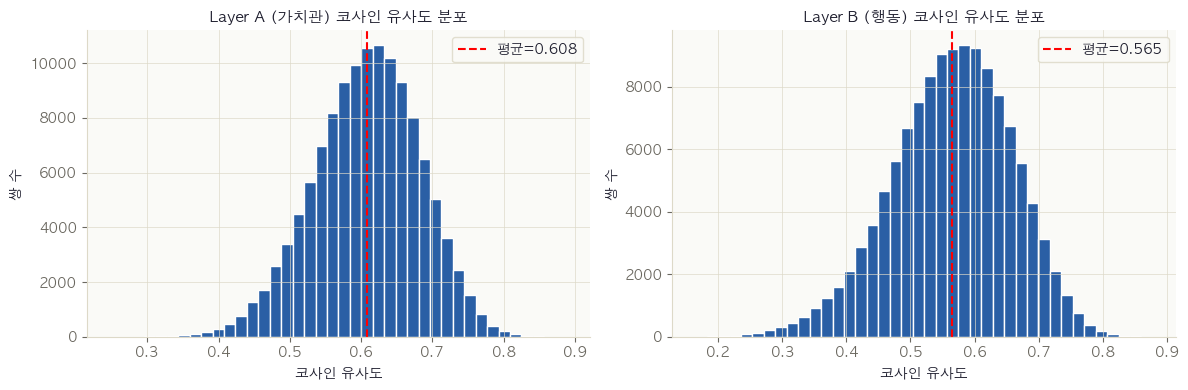

Layer A 평균 유사도: 0.608
Layer B 평균 유사도: 0.565


In [9]:
from sklearn.metrics.pairwise import cosine_similarity

# 무작위 500쌍 샘플링
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_a), size=500, replace=False)
sim_a = cosine_similarity(X_a[idx])
sim_b = cosine_similarity(X_b[idx])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sim, title in [
    (axes[0], sim_a[np.triu_indices_from(sim_a, k=1)], 'Layer A (가치관) 코사인 유사도 분포'),
    (axes[1], sim_b[np.triu_indices_from(sim_b, k=1)], 'Layer B (행동) 코사인 유사도 분포'),
]:
    ax.hist(sim, bins=40, color=T.CHEONG, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('코사인 유사도')
    ax.set_ylabel('쌍 수')
    ax.axvline(np.mean(sim), color='red', linestyle='--', label=f'평균={np.mean(sim):.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('../image/nb03/embedding_similarity_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Layer A 평균 유사도: {np.mean(sim_a[np.triu_indices_from(sim_a, k=1)]):.3f}")
print(f"Layer B 평균 유사도: {np.mean(sim_b[np.triu_indices_from(sim_b, k=1)]):.3f}")

> **임베딩 품질 해석**
> - **코사인 유사도 평균 0.3~0.6**: 텍스트 간 적절한 분산 — 군집화 가능 구간
> - **평균 0.8 이상**: 합성 텍스트의 표현이 지나치게 유사 → LLM 생성 편향 신호. 이 경우 군집 경계가 흐려질 수 있음
> - **Layer A vs B 비교**: 가치관 텍스트(Layer A)의 유사도가 행동(Layer B)보다 높으면, 가치관 표현이 더 균질함을 의미 — 반드시 원문을 읽어 확인

---
## 섹션 4. 차원 축소 — UMAP

768D 임베딩을 직접 군집화하면 Curse of Dimensionality로 거리 개념이 무너진다.
UMAP 50D로 압축해 군집화 입력으로 사용하고, 2D는 시각화 전용이다.
두 레이어를 나란히 그려 **가치관 공간과 행동 공간의 구조 차이**를 먼저 확인한다.

In [10]:
import umap

print("Layer A UMAP 계산 중...")
reducer_2d_a = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
X_a_2d = reducer_2d_a.fit_transform(X_a)

reducer_50d_a = umap.UMAP(n_components=50, n_neighbors=15, min_dist=0.0, random_state=RANDOM_STATE)
X_a_50d = reducer_50d_a.fit_transform(X_a)
print("Layer A 완료")

print("Layer B UMAP 계산 중...")
reducer_2d_b = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
X_b_2d = reducer_2d_b.fit_transform(X_b)

reducer_50d_b = umap.UMAP(n_components=50, n_neighbors=15, min_dist=0.0, random_state=RANDOM_STATE)
X_b_50d = reducer_50d_b.fit_transform(X_b)
print("Layer B 완료")

sample_df['umap_a_x'] = X_a_2d[:, 0]
sample_df['umap_a_y'] = X_a_2d[:, 1]
sample_df['umap_b_x'] = X_b_2d[:, 0]
sample_df['umap_b_y'] = X_b_2d[:, 1]

Layer A UMAP 계산 중...
Layer A 완료
Layer B UMAP 계산 중...
Layer B 완료


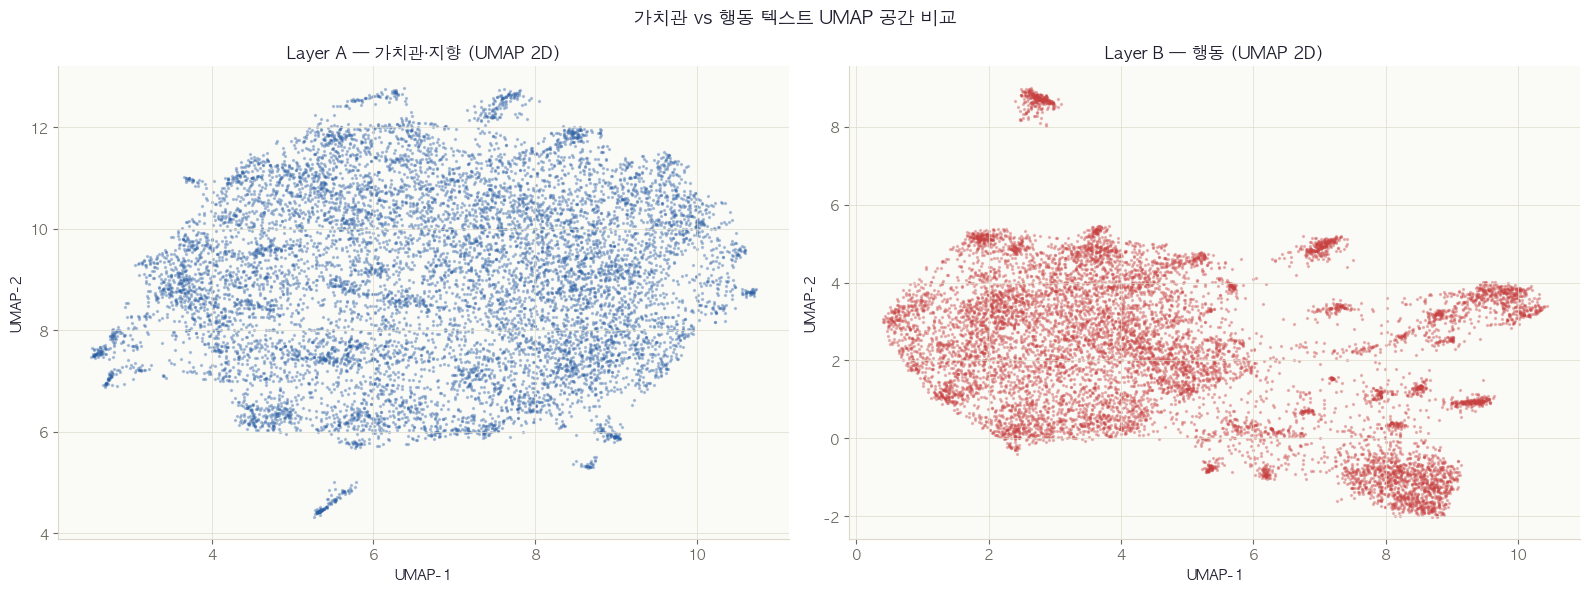

In [11]:
# Layer A vs B UMAP 2D 나란히 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_a_2d[:, 0], X_a_2d[:, 1], s=2, alpha=0.3, color=T.CHEONG)
axes[0].set_title('Layer A — 가치관·지향 (UMAP 2D)', fontsize=12)
axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2')

axes[1].scatter(X_b_2d[:, 0], X_b_2d[:, 1], s=2, alpha=0.3, color=T.JEOK)
axes[1].set_title('Layer B — 행동 (UMAP 2D)', fontsize=12)
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')

plt.suptitle('가치관 vs 행동 텍스트 UMAP 공간 비교', fontsize=13)
plt.tight_layout()
plt.savefig('../image/nb03/umap_raw_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

> **UMAP 공간 비교**
> - Layer A(가치관)가 뚜렷한 덩어리로 나뉘어 있으면 → 가치관 기반 군집화가 의미 있음을 시각적으로 확인
> - Layer B(행동)가 더 연속적·균질하게 분포하면 → 행동 다양성이 높거나 합성 텍스트가 균질함
> - 두 공간의 구조가 다를수록 섹션 8 교차 분석에서 **"같은 가치관, 다른 행동"** 패턴이 나올 가능성이 높음

---
## 섹션 5. 군집화 — Layer A (K-Means + HDBSCAN)

K=3~10 전체를 돌려 Elbow·Silhouette·Davies-Bouldin 세 지표를 동시에 확인한다.
세 지표 중 2개 이상에서 상위권인 K를 OPTIMAL_K로 선택하고, 선택 근거를 주석에 명시한다.
HDBSCAN은 비교 실험으로만 사용한다 — K-Means 결과와 구조가 유사하면 K-Means 결과를 신뢰.

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

K_RANGE = range(3, 11)
results = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_a_50d)
    sil = silhouette_score(X_a_50d, labels, sample_size=3000, random_state=RANDOM_STATE)
    db = davies_bouldin_score(X_a_50d, labels)
    results.append({'K': k, 'inertia': km.inertia_, 'silhouette': sil, 'davies_bouldin': db})
    print(f"K={k}: inertia={km.inertia_:.0f}, silhouette={sil:.4f}, DB={db:.4f}")

results_df = pd.DataFrame(results).set_index('K')
results_df

K=3: inertia=18987, silhouette=0.2819, DB=1.3055
K=4: inertia=15866, silhouette=0.2725, DB=1.2044
K=5: inertia=13032, silhouette=0.3015, DB=1.1805
K=6: inertia=11628, silhouette=0.3026, DB=1.2628
K=7: inertia=10601, silhouette=0.3078, DB=1.2139
K=8: inertia=9903, silhouette=0.3054, DB=1.1676
K=9: inertia=9293, silhouette=0.2915, DB=1.1819
K=10: inertia=8693, silhouette=0.2905, DB=1.2090


,inertia,silhouette,davies_bouldin
K,,,
3,18986.582031,0.281896,1.305532
4,15865.660156,0.272474,1.204382
5,13031.601562,0.301502,1.180461
6,11627.597656,0.302601,1.262809
7,10601.077148,0.307809,1.213879
8,9902.601562,0.305421,1.167610
9,9293.468750,0.291475,1.181936
10,8692.539062,0.290514,1.208983


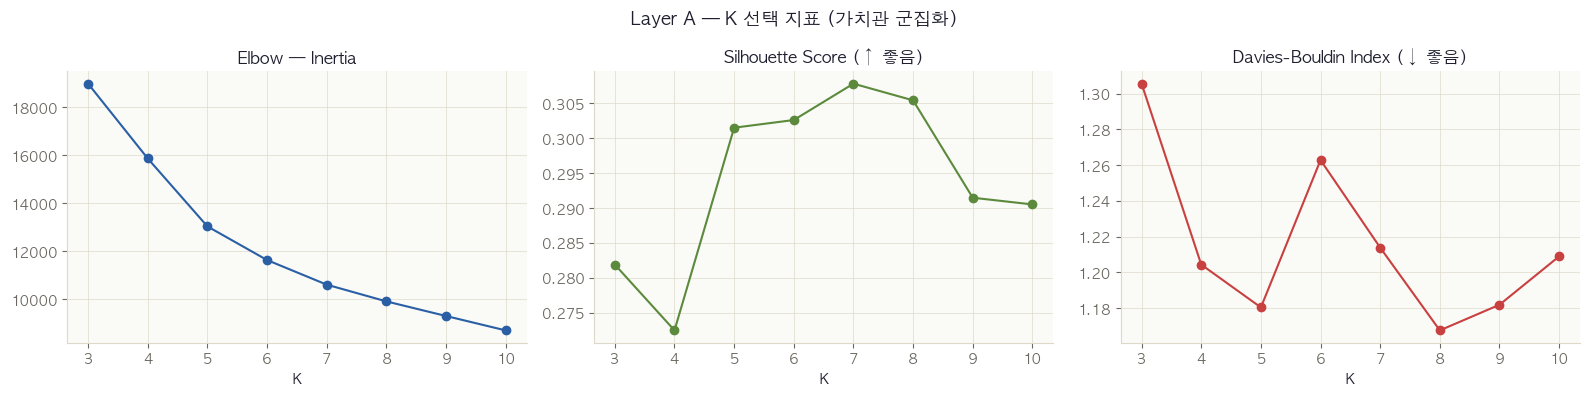

In [13]:
# 세 지표 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ks = list(K_RANGE)

axes[0].plot(ks, results_df['inertia'], 'o-', color=T.CHEONG)
axes[0].set_title('Elbow — Inertia'); axes[0].set_xlabel('K')

axes[1].plot(ks, results_df['silhouette'], 'o-', color=T.SONAMU)
axes[1].set_title('Silhouette Score (↑ 좋음)'); axes[1].set_xlabel('K')

axes[2].plot(ks, results_df['davies_bouldin'], 'o-', color=T.JEOK)
axes[2].set_title('Davies-Bouldin Index (↓ 좋음)'); axes[2].set_xlabel('K')

plt.suptitle('Layer A — K 선택 지표 (가치관 군집화)', fontsize=13)
plt.tight_layout()
plt.savefig('../image/nb03/kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

> **K 선택 근거**
>
> | K | Inertia | Silhouette | Davies-Bouldin |
> |---|---------|------------|----------------|
> | (실행 후 기입) | | ↑ 높을수록 좋음 | ↓ 낮을수록 좋음 |
>
> - **OPTIMAL_K = (실행 후 기입)** — Silhouette·DB 두 지표 중 2개 이상 상위권 기준
> - Elbow 꺾이는 지점 + Silhouette 고점 + DB 저점이 겹치는 K 선택
> - K-Means vs HDBSCAN 비교 후 구조 유사하면 K-Means 결과 신뢰

In [14]:
OPTIMAL_K = 5

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
sample_df['cluster_a'] = km_final.fit_predict(X_a_50d)

cluster_counts = sample_df['cluster_a'].value_counts().sort_index()
print(f"최적 K = {OPTIMAL_K}")
print(cluster_counts)

# 1% 미만 소수 군집 자동 탐지 및 제외
threshold = int(len(sample_df) * 0.01)
tiny = cluster_counts[cluster_counts < threshold].index.tolist()
if tiny:
    print(f"\n⚠️  소수 군집 ({threshold}행 미만) 탐지: {tiny} → 분석 제외")
    sample_df = sample_df[~sample_df['cluster_a'].isin(tiny)].copy()
    print(f"제외 후 샘플: {len(sample_df):,}행")
else:
    print("\n✓ 소수 군집 없음")

최적 K = 5
cluster_a
0    3012
1    1912
2    1610
3    2036
4    1930
Name: count, dtype: int64

✓ 소수 군집 없음


In [15]:
# HDBSCAN 비교
!pip install hdbscan -q
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=150, min_samples=10)
sample_df['cluster_a_hdb'] = clusterer.fit_predict(X_a_50d[:len(sample_df)])

n_hdb = len(set(sample_df['cluster_a_hdb'])) - (1 if -1 in sample_df['cluster_a_hdb'].values else 0)
n_noise = (sample_df['cluster_a_hdb'] == -1).sum()
print(f"HDBSCAN: {n_hdb}개 군집, 노이즈 {n_noise:,}행 ({n_noise/len(sample_df):.1%})")

HDBSCAN: 3개 군집, 노이즈 632행 (6.0%)


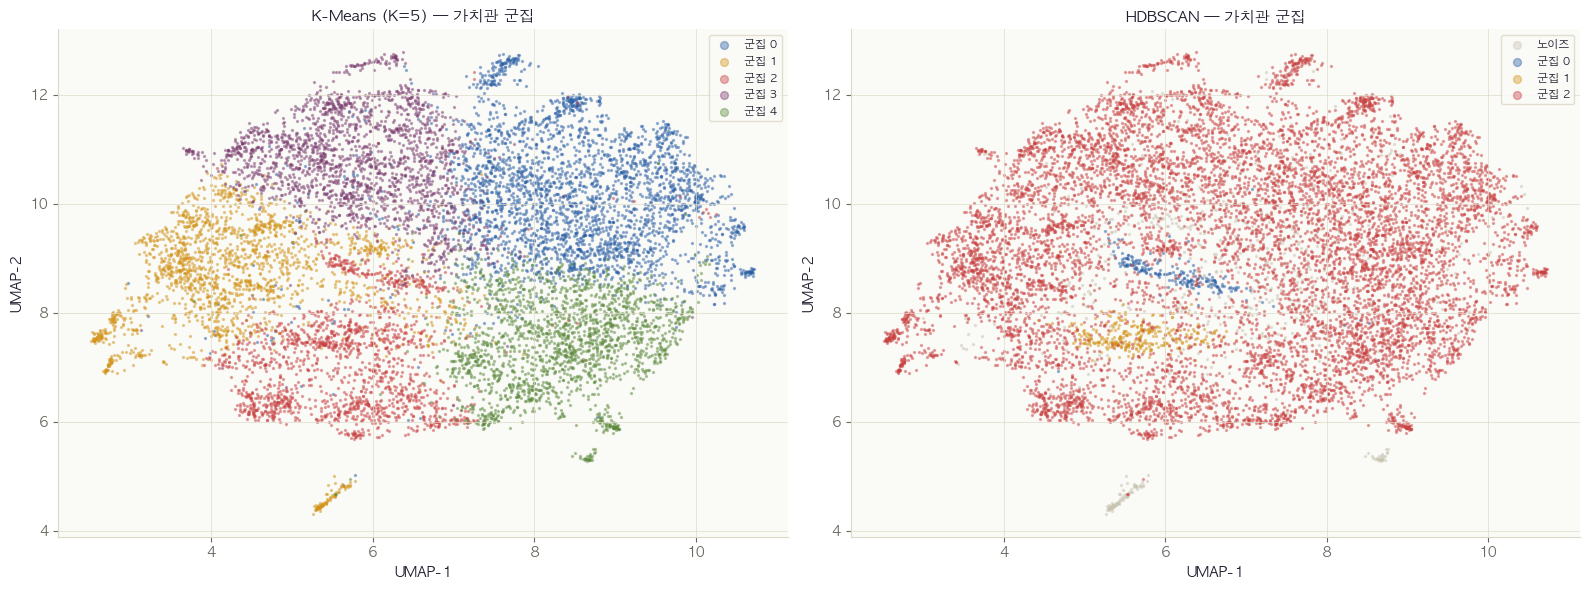

In [16]:
# K-Means vs HDBSCAN UMAP 비교

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in [
    (axes[0], 'cluster_a', f'K-Means (K={OPTIMAL_K}) — 가치관 군집'),
    (axes[1], 'cluster_a_hdb', f'HDBSCAN — 가치관 군집'),
]:
    labels = sample_df[col]
    X_2d = X_a_2d[:len(sample_df)]
    for lbl in sorted(labels.unique()):
        mask = (labels == lbl).values
        color = T.NOISE if lbl == -1 else T.CYCLE[lbl % len(T.CYCLE)]
        name = '노이즈' if lbl == -1 else f'군집 {lbl}'
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=2, alpha=0.4, color=color, label=name)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.legend(markerscale=4, fontsize=8)

plt.tight_layout()
plt.savefig('../image/nb03/clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 섹션 6. 군집 해석 — 원문 직접 읽기 + TF-IDF 키워드

**가장 중요한 섹션**. 키워드만 보면 뉘앙스를 놓친다.
원문을 직접 읽고 각 군집이 "무엇을 원하고 무엇을 중요하게 여기는가"를 파악한 뒤 이름을 붙인다.
인구통계도 함께 출력해 다양한 연령·성별이 섞여 있는지 육안으로 먼저 확인한다.

In [17]:
for cluster_id in sorted(sample_df['cluster_a'].unique()):
    cluster_size = (sample_df['cluster_a'] == cluster_id).sum()
    print(f"\n{'=' * 65}")
    print(f" 군집 {cluster_id}  |  {cluster_size}명 ({cluster_size/len(sample_df):.1%})")
    print(f"{'=' * 65}")

    samples = sample_df[sample_df['cluster_a'] == cluster_id].sample(
        min(3, cluster_size), random_state=RANDOM_STATE)

    for _, row in samples.iterrows():
        print(f"\n  [정체성]  {row['persona']}")
        print(f"  [가치관]  {str(row['cultural_background'])[:100]}...")
        print(f"  [지향  ]  {row['career_goals_and_ambitions']}")
        print(f"  [행동   ]  {str(row['hobbies_and_interests'])[:60]}...")
        print(f"  [인구통계]  {int(row['age'])}세 {row['sex']} / {row['province']} / {row['education_level']}")
        print(f"  [직업    ]  {row['occupation']}")
        print(f"  {'-' * 55}")


 군집 0  |  3012명 (28.7%)

  [정체성]  허지성 씨는 송파구에서 자취하며 식당 경리로 일하는 21세 청년으로, 철저한 자기관리와 정산 능력을 바탕으로 더 큰 기업으로의 도약을 준비하고 있습니다.
  [가치관]  송파구 가락동 인근의 소형 아파트에서 자취하며, 전문대 졸업 후 빠르게 사회에 뛰어들어 실무 중심의 생활 양식을 갖추고 있습니다. 유튜브 쇼츠나 릴스로 최신 트렌드를 빠르게 접하며...
  [지향  ]  현재의 낮은 급여 수준을 극복하기 위해 퇴근 후 전산회계 자격증 공부에 매진하고 있으며, 향후 규모가 큰 외식 프랜차이즈 본사의 경영지원팀으로 이직해 안정적인 소득 기반을 마련하고자 합니다.
  [행동   ]  주말이면 송파구 내 공원 농구 코트에서 땀 흘리며 경기를 뛰거나, 단골 당구장에서 친구들과 3구 게임을 하며...
  [인구통계]  21세 남자 / 서울 / 2~3년제 전문대학
  [직업    ]  경리 사무원
  -------------------------------------------------------

  [정체성]  김호철 씨는 강남의 자가 아파트에서 어머니와 함께 지내며, 공학적 전문성을 뒤로한 채 소박한 일상과 심리적 평온을 추구하는 40대 후반의 남성입니다.
  [가치관]  강남구의 오래된 아파트에서 연로하신 어머니를 모시며, 90년대 대학 시절의 자유분방함과 대학원 과정의 엄격한 규율을 모두 경험하며 성장했습니다. 학위라는 사회적 성취를 이뤘음에도 ...
  [지향  ]  거창한 재취업이나 사회적 성공보다는, 자신이 가진 전문 지식을 가볍게 나눌 수 있는 파트타임 자문직이나 소규모 프로젝트에 참여하며 적당한 사회적 끈을 유지하기를 바랍니다. 무리하게 삶의 궤도를 바꾸기보다 현재의 심리적 안정감을 해치지 않는 선에서 소박한 경제 활동을 찾는 것에 만족합니다.
  [행동   ]  주말이면 청계산의 완만한 산책로를 천천히 오르며 복잡한 생각을 정리하고, 저녁에는 유튜브로 오래된 세계사 다...
  [인구통계]

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

def get_group_keywords(df, group_col, text_col='layer_a_norm', top_n=15):
    groups = df.groupby(group_col, observed=True)[text_col].apply(' '.join)
    tfidf = TfidfVectorizer(max_features=3000)
    matrix = tfidf.fit_transform(groups.values)
    terms = tfidf.get_feature_names_out()
    
    result = {}
    for i, grp in enumerate(groups.index):
        scores = matrix[i].toarray().flatten()
        top_idx = scores.argsort()[::-1][:top_n]
        result[grp] = [(terms[j], scores[j]) for j in top_idx if scores[j] > 0]
    return result

# Layer A(가치관 군집)의 키워드 추출
cluster_keywords_a = get_group_keywords(sample_df, 'cluster_a', 'layer_a_norm', top_n=15)


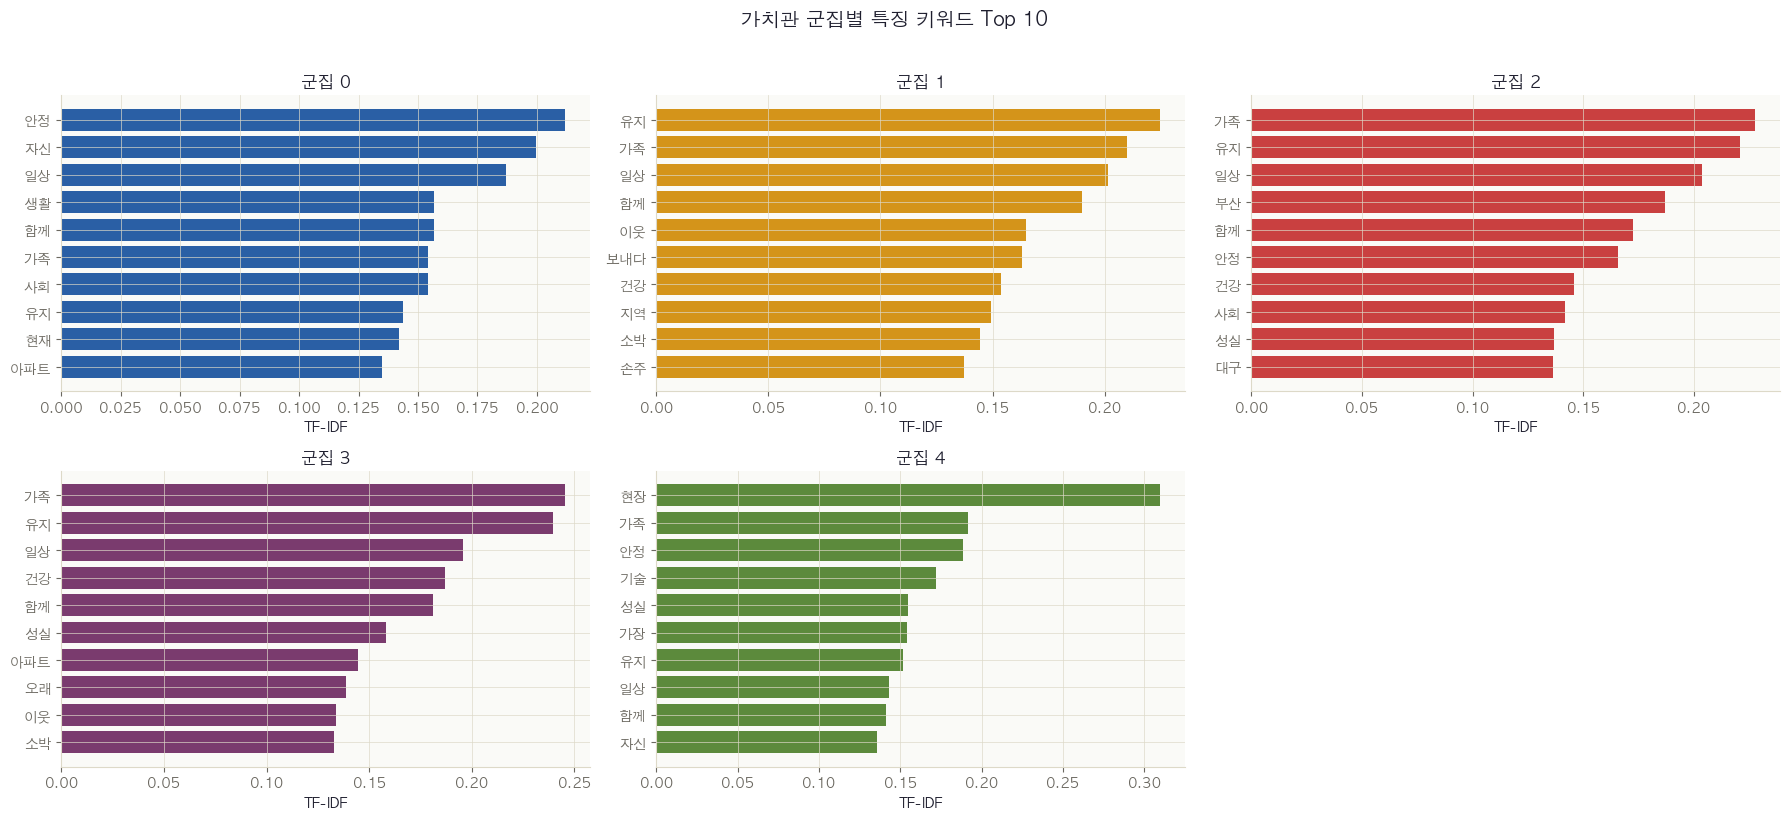

In [19]:
# 군집별 키워드 막대 차트
n_clusters = len(sample_df['cluster_a'].unique())
cols_grid = min(n_clusters, 3)
rows_grid = (n_clusters + cols_grid - 1) // cols_grid
fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(6 * cols_grid, 4 * rows_grid))
axes = np.array(axes).flatten()
colors = color_list(n_clusters)

for i, (cluster_id, kws) in enumerate(cluster_keywords_a.items()):
    words = [w for w, _ in kws[:10]]
    scores = [s for _, s in kws[:10]]
    axes[i].barh(words[::-1], scores[::-1], color=colors[i])
    axes[i].set_title(f'군집 {cluster_id}', fontsize=12)
    axes[i].set_xlabel('TF-IDF')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('가치관 군집별 특징 키워드 Top 10', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../image/nb03/cluster_a_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

> **군집별 키워드 해석 포인트**
> - 각 막대 차트에서 **다른 군집에 없는 단어**가 해당 군집의 핵심 가치관 지표
> - TF-IDF는 절대 빈도가 아닌 상대 차이 — 흔한 단어(`자신`, `삶`)가 높게 나오면 해당 군집에서 특히 강조됨
> - 아래 셀에서 원문을 읽고 키워드의 맥락(어떤 문장에서 등장하는지)을 확인한 뒤 이름 결정

In [20]:
CLUSTER_NAMES_A = {
    0: '자기계발·전환 모색형',
    1: '소박 일상·지역 공동체형',
    2: '현실적 목표 실천형',
    3: '관계·가족 중심형',
    4: '책임·안정 지향형',
}
sample_df['cluster_a_name'] = sample_df['cluster_a'].map(CLUSTER_NAMES_A)
print(sample_df[['cluster_a', 'cluster_a_name']].drop_duplicates().sort_values('cluster_a').to_string(index=False))

 cluster_a cluster_a_name
         0    자기계발·전환 모색형
         1  소박 일상·지역 공동체형
         2     현실적 목표 실천형
         3      관계·가족 중심형
         4      책임·안정 지향형


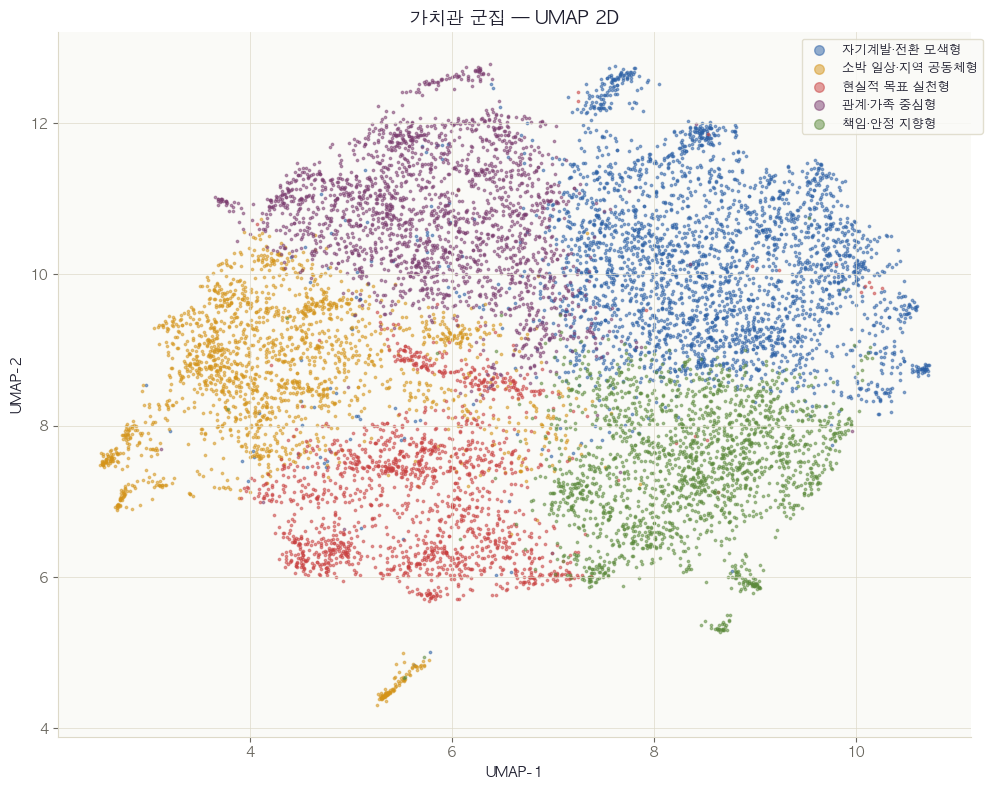

In [21]:
# UMAP 2D — 군집 색상 표시
fig, ax = plt.subplots(figsize=(10, 8))
for i, cluster_id in enumerate(sorted(sample_df['cluster_a'].unique())):
    mask = (sample_df['cluster_a'] == cluster_id).values
    name = CLUSTER_NAMES_A.get(cluster_id, f'군집 {cluster_id}')
    ax.scatter(X_a_2d[mask, 0], X_a_2d[mask, 1],
               s=3, alpha=0.5, color=colors[i], label=name)

ax.set_title('가치관 군집 — UMAP 2D', fontsize=13)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(markerscale=4, fontsize=9, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('../image/nb03/cluster_a_umap.png', dpi=150, bbox_inches='tight')
plt.show()

> **군집 네이밍 가이드**
> - 원문에서 반복되는 **동사·형용사**가 가치관 방향을 결정한다 (`나누고 싶다` → 공동체 지향, `스스로` → 자율 지향)
> - TF-IDF 키워드는 다른 군집과의 **상대적 차이**를 보여준다 — 절대 빈도가 아님에 주의
> - 같은 TF-IDF 키워드라도 문장 맥락이 다르면 지향점이 반대일 수 있다 → 반드시 원문으로 검증
> - 인구통계(나이·성별)가 다양하게 섞인 군집 = 가치관이 인구통계와 독립적 → 논문 핵심 주장의 직접 증거

---
## 섹션 7. 반전 분석 A — 가치관 군집 × 인구통계

**논문의 핵심 주장을 실증하는 섹션**.
가치관 기반으로 나눈 군집에 연령·성별·지역·학력이 고르게 섞여 있다면,
"50대 여성 = 등산·트로트" 같은 인구통계 스테레오타입이 데이터로 반박된다.
4개 Heatmap과 Sankey로 시각적으로 증명한다.

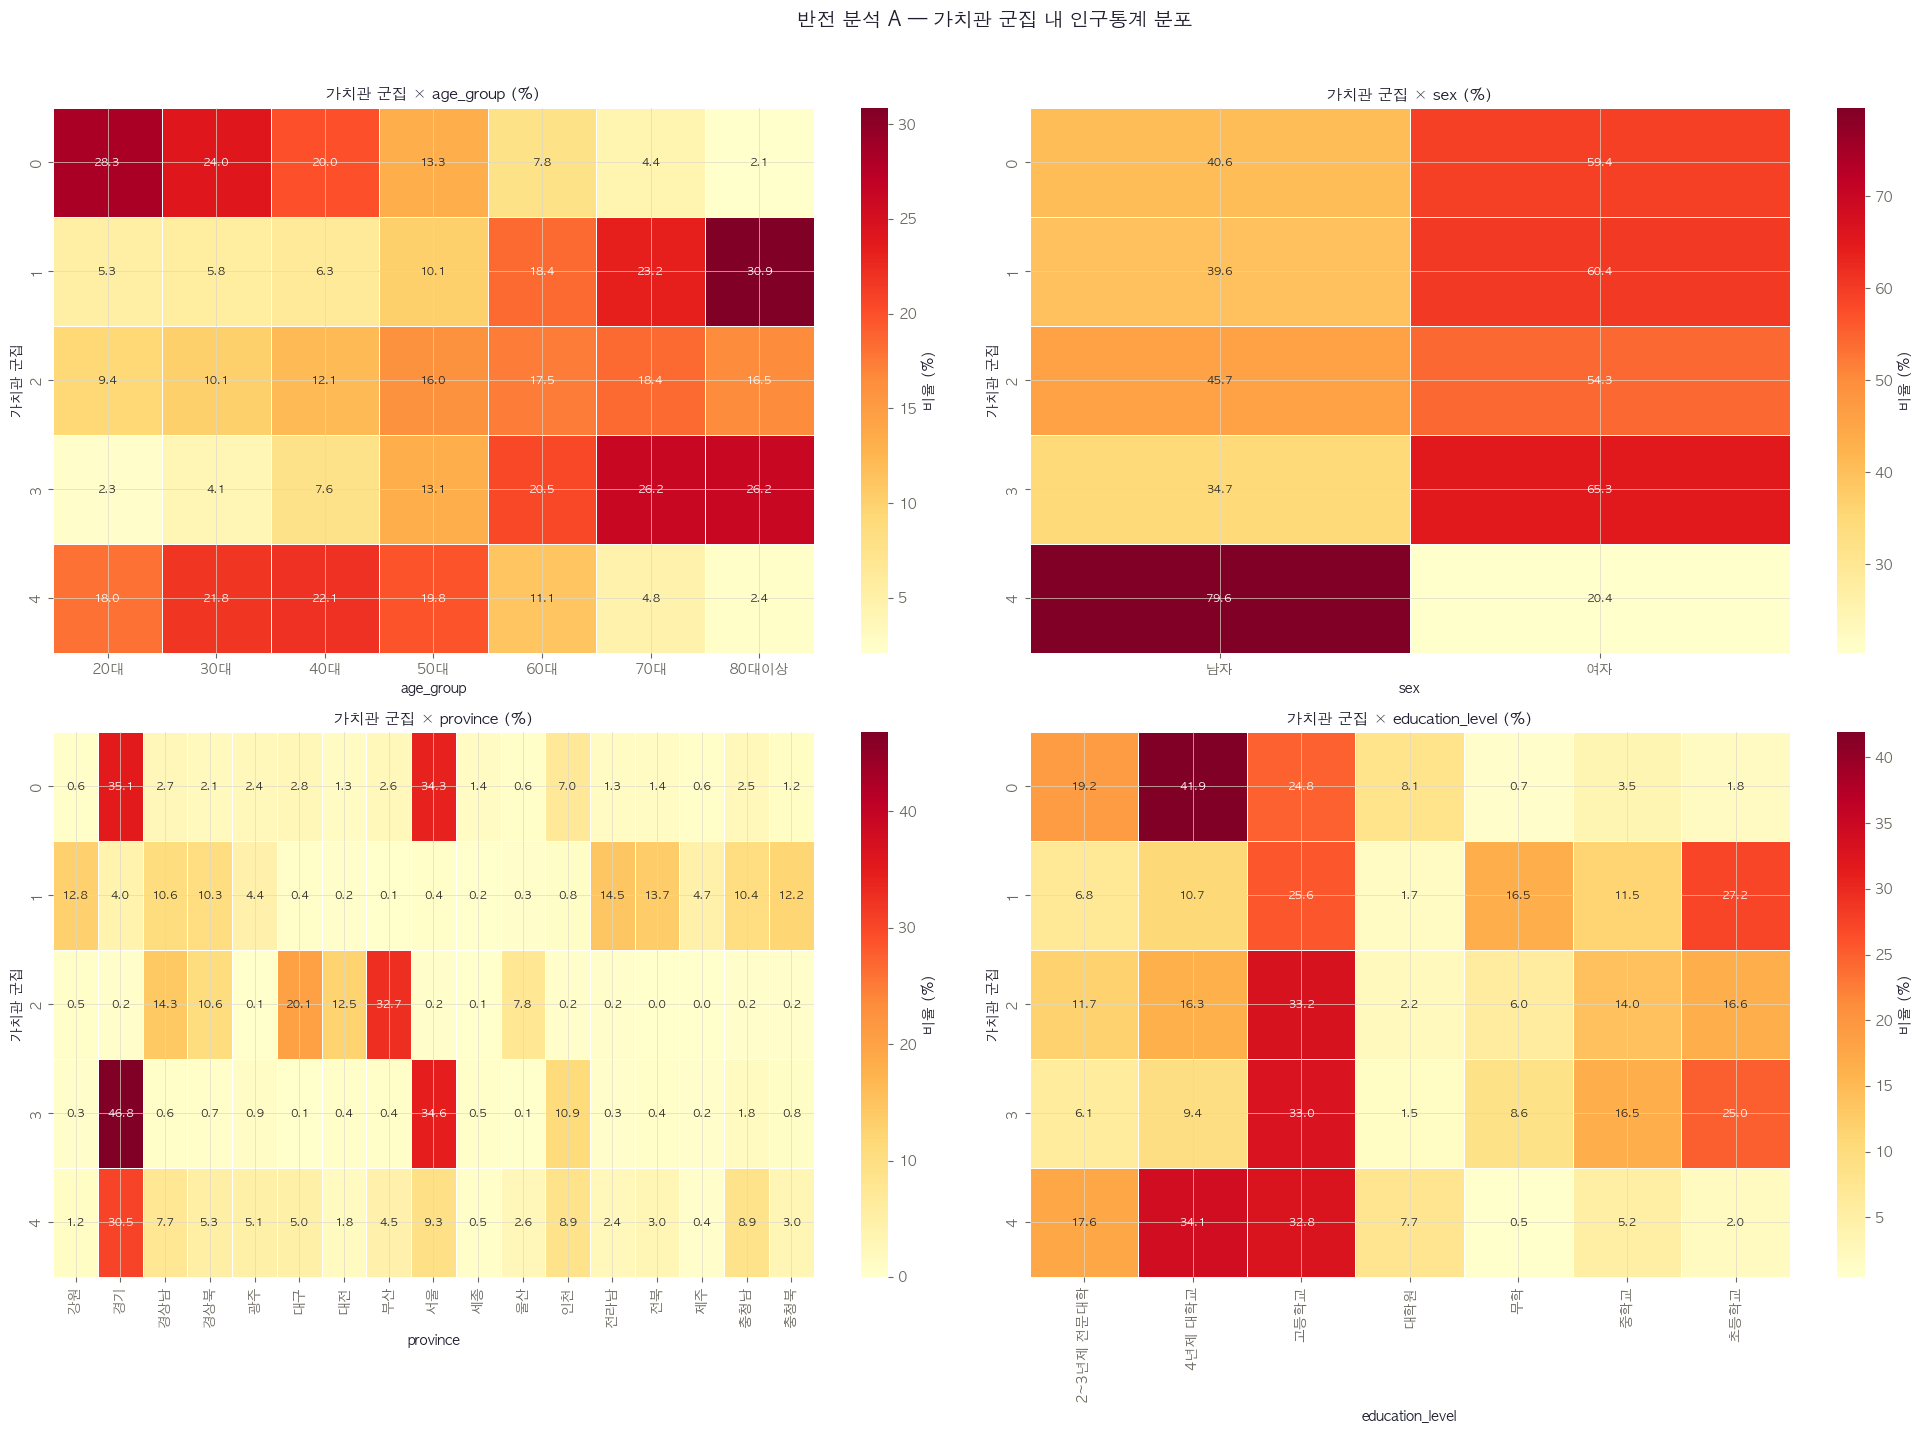

In [22]:
import seaborn as sns

demo_targets = ['age_group', 'sex', 'province', 'education_level']
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for ax, col in zip(axes, demo_targets):
    pivot = sample_df.groupby(['cluster_a', col], observed=True).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    sns.heatmap(
        pivot_pct, ax=ax, cmap='YlOrRd',
        annot=True, fmt='.1f', annot_kws={'size': 8},
        cbar_kws={'label': '비율 (%)'},
        linewidths=0.5
    )
    ax.set_title(f'가치관 군집 × {col} (%)', fontsize=11)
    ax.set_xlabel(col); ax.set_ylabel('가치관 군집')

plt.suptitle('반전 분석 A — 가치관 군집 내 인구통계 분포', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../image/nb03/reverse_a_demo.png', dpi=150, bbox_inches='tight')
plt.show()

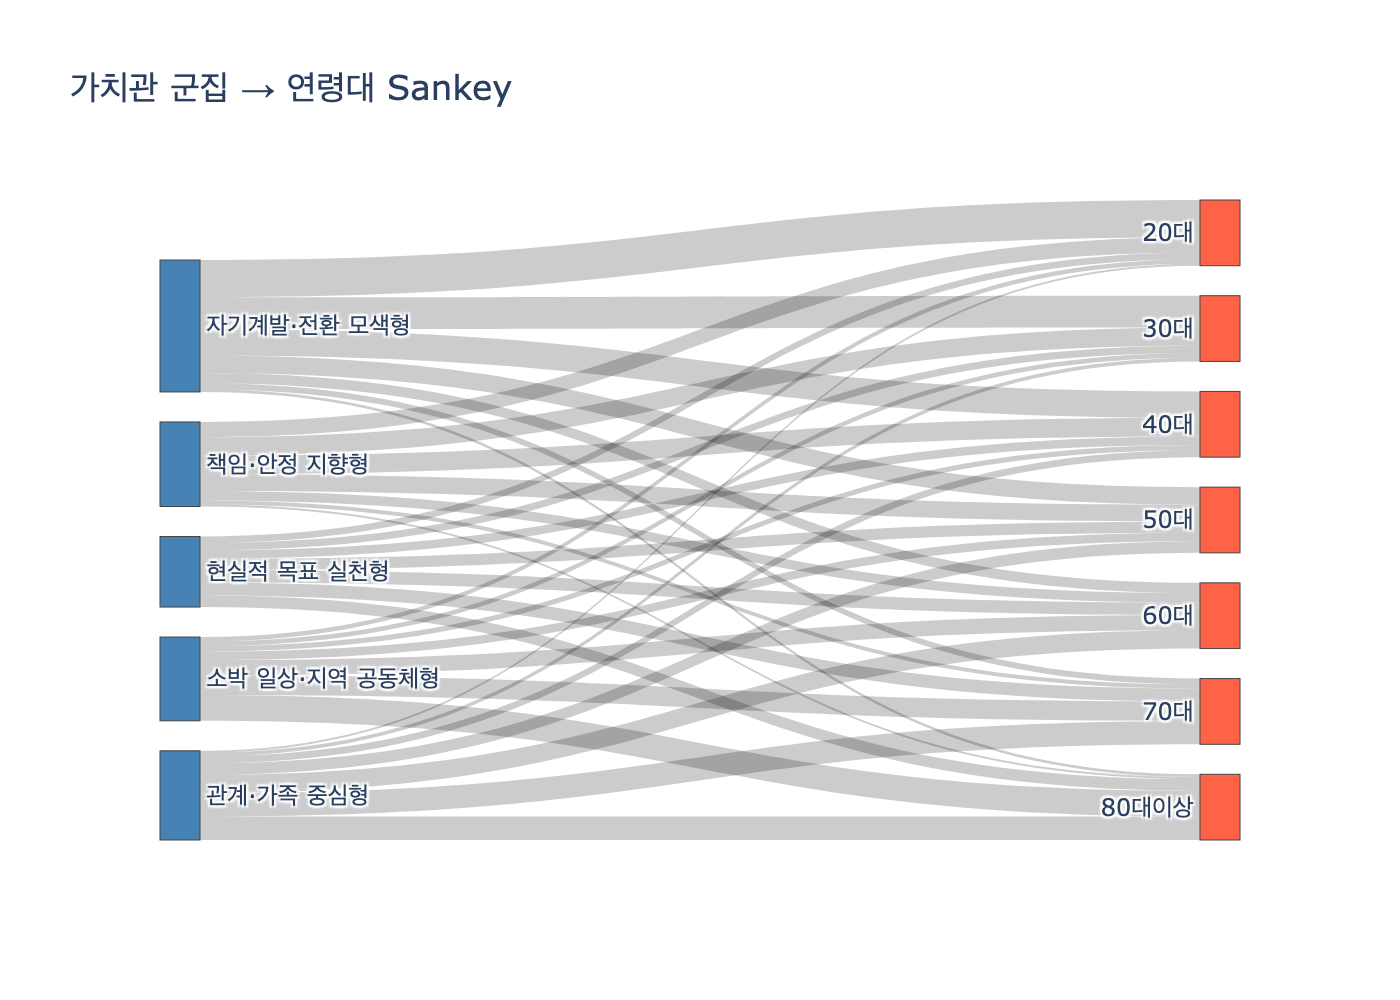

In [23]:
# Sankey — 가치관 군집 → 연령대 흐름
!pip install plotly kaleido -q
import plotly.graph_objects as go
from IPython.display import Image

sankey_data = sample_df.groupby(['cluster_a', 'age_group'], observed=True).size().reset_index(name='count')
clusters = sorted(sample_df['cluster_a'].unique())
age_groups = list(sample_df['age_group'].cat.categories)

node_labels = [CLUSTER_NAMES_A.get(c, f'군집 {c}') for c in clusters] + age_groups
cluster_idx = {c: i for i, c in enumerate(clusters)}
age_idx = {a: len(clusters) + i for i, a in enumerate(age_groups)}

sources, targets, values = [], [], []
for _, row in sankey_data.iterrows():
    sources.append(cluster_idx[row['cluster_a']])
    targets.append(age_idx[row['age_group']])
    values.append(row['count'])

fig = go.Figure(go.Sankey(
    node=dict(pad=15, thickness=20, label=node_labels,
              color=['steelblue'] * len(clusters) + ['tomato'] * len(age_groups)),
    link=dict(source=sources, target=targets, value=values)
))
fig.update_layout(title='가치관 군집 → 연령대 Sankey', font_size=12, height=500)
fig.write_image('../image/nb03/sankey_age.png', scale=2)
Image('../image/nb03/sankey_age.png')

> **반전 분석 A — 핵심 판독 기준**
> - **Heatmap 행 분포가 고름**: 해당 군집은 특정 연령·성별에 편중되지 않음 → 가치관이 인구통계를 초월함
> - **특정 셀이 붉게 튀어나옴**: 해당 인구통계와 가치관 군집 간 실제 상관 존재 → Discussion에서 원인 분석 필요
> - **Sankey 흐름 분산**: 각 군집에서 여러 연령대로 흐름이 분산될수록 스테레오타입 반박 근거 강화
> - **Amershi G6 연결**: 인구통계 편중이 없음이 확인되면, 행동 군집 대신 가치관 군집 기반 AI 설계가 G6(편향 완화)를 충족함을 논증 가능

---
## 섹션 8. 반전 분석 B — 가치관 군집 × 행동 군집

**이 노트북에서만 볼 수 있는 핵심 분석**.
같은 가치관을 가진 사람이 다른 행동을 하는가?
교차 Heatmap 대각선 집중도가 낮을수록 → 가치관과 행동이 독립적 → AI 에이전트 설계 시 두 레이어를 분리해야 한다는 근거가 된다.

In [24]:
# 가치관 군집 × 행동 군집 교차 분석

# Layer B 군집화 (동일 K)
km_b = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
sample_df['cluster_b'] = km_b.fit_predict(X_b_50d[:len(sample_df)])

print("Layer B 군집 분포:")
print(sample_df['cluster_b'].value_counts().sort_index())

Layer B 군집 분포:
cluster_b
0    4746
1    2084
2     820
3     250
4    2600
Name: count, dtype: int64


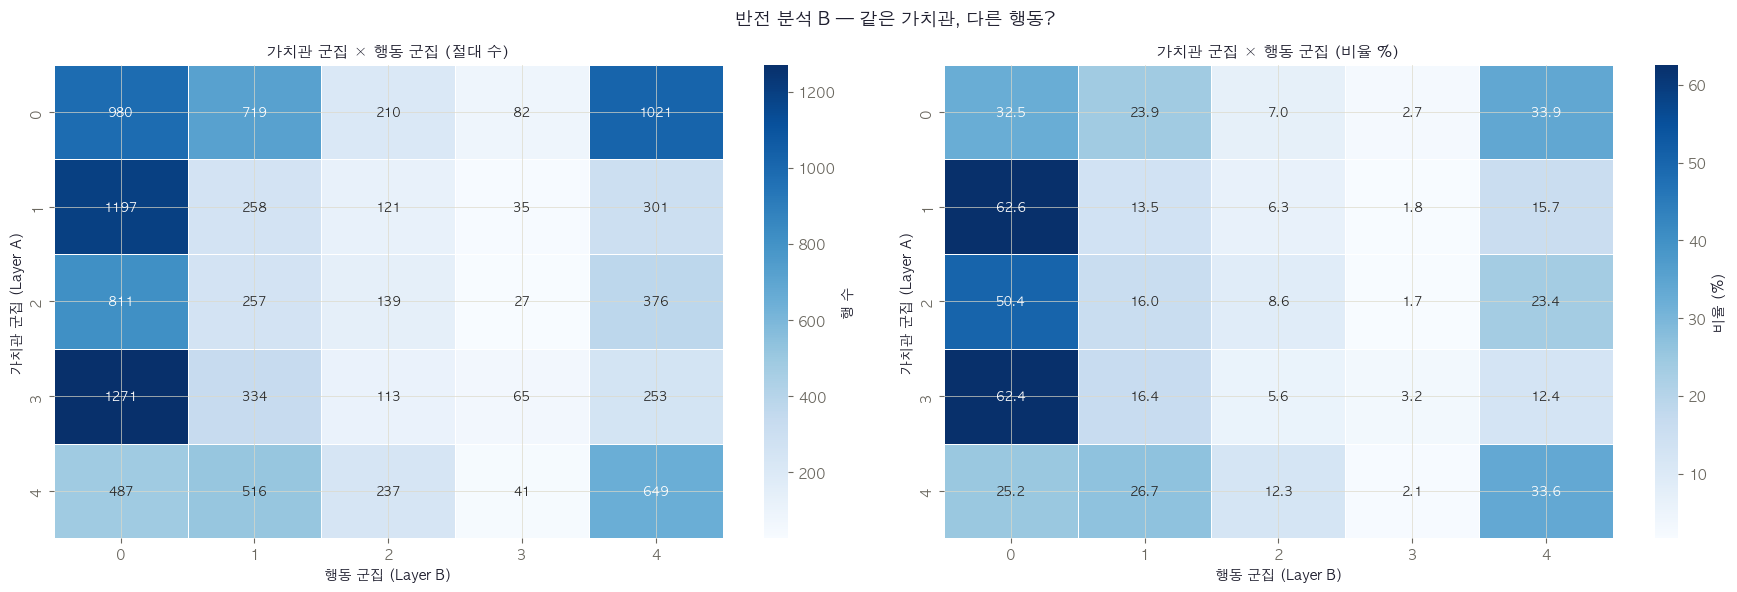


[해석 힌트]
대각선 평균 비율: 18.3%
  → 높으면: 가치관과 행동이 일치하는 경향
  → 낮으면: 같은 가치관 → 다른 행동 (가치관이 행동을 결정하지 않음)


In [25]:
# 가치관 군집 × 행동 군집 교차 Heatmap
cross = sample_df.groupby(['cluster_a', 'cluster_b']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 절대 수
sns.heatmap(
    cross, ax=axes[0], cmap='Blues',
    annot=True, fmt='d', annot_kws={'size': 9},
    linewidths=0.5, cbar_kws={'label': '행 수'}
)
axes[0].set_title('가치관 군집 × 행동 군집 (절대 수)', fontsize=11)
axes[0].set_xlabel('행동 군집 (Layer B)'); axes[0].set_ylabel('가치관 군집 (Layer A)')

# 비율
sns.heatmap(
    cross_pct, ax=axes[1], cmap='Blues',
    annot=True, fmt='.1f', annot_kws={'size': 9},
    linewidths=0.5, cbar_kws={'label': '비율 (%)'}
)
axes[1].set_title('가치관 군집 × 행동 군집 (비율 %)', fontsize=11)
axes[1].set_xlabel('행동 군집 (Layer B)'); axes[1].set_ylabel('가치관 군집 (Layer A)')

plt.suptitle('반전 분석 B — 같은 가치관, 다른 행동?', fontsize=13)
plt.tight_layout()
plt.savefig('../image/nb03/cross_ab.png', dpi=150, bbox_inches='tight')
plt.show()

# 해석 출력
print("\n[해석 힌트]")
print(f"대각선 평균 비율: {np.mean([cross_pct.iloc[i, i] for i in range(min(cross_pct.shape))]):.1f}%")
print("  → 높으면: 가치관과 행동이 일치하는 경향")
print("  → 낮으면: 같은 가치관 → 다른 행동 (가치관이 행동을 결정하지 않음)")

In [26]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

# Kiwi를 활용한 명사 추출 토크나이저 정의
def korean_noun_tokenizer(text):
    try:
        tokens = kiwi.tokenize(text)
        # NNG(일반 명사), NNP(고유 명사) 중 1글자 초과인 단어만 추출
        return [t.form for t in tokens if t.tag in ('NNG', 'NNP') and len(t.form) > 1]
    except:
        return []

# 자주 등장하지만 의미가 없는 기본적인 불용어 리스트
korean_stop_words = ['하다', '되다', '있다', '사람', '생각', '때문', '경우', '정도']

In [27]:
# 1. Kiwi 객체 생성 시 병렬 처리 스레드 수 설정 (코어 수에 맞춰 설정, 예: 8)
from kiwipiepy import Kiwi
kiwi = Kiwi(num_workers=8) 

def get_nouns_fast(texts):
    results = []
    # analyze()에 리스트(texts)를 넣으면 자동으로 위에서 설정한 num_workers 만큼 병렬 처리
    for analysis in tqdm(kiwi.analyze(texts), total=len(texts), desc="명사 추출 중"):
        # analysis는 [(tokens, score), ...] 형태의 리스트이므로 첫 번째 결과의 토큰들을 가져옴
        tokens = analysis[0][0] 
        nouns = [t.form for t in tokens if t.tag in ('NNG', 'NNP') and len(t.form) > 1]
        results.append(' '.join(nouns))
    return results

# 2. 전체 데이터에 대해 미리 명사 추출
print("TF-IDF용 명사 추출...")
sample_df['layer_b_nouns'] = get_nouns_fast(sample_df['layer_b_text'].tolist())

# 3. 최적화된 TF-IDF 실행 (이전과 동일)
groups_b = sample_df.groupby('cluster_b', observed=True)['layer_b_nouns'].apply(' '.join)

tfidf_b = TfidfVectorizer(
    max_features=3000,
    tokenizer=None, 
    stop_words=korean_stop_words,
    token_pattern=r"(?u)\b\w\w+\b"
)

print("TF-IDF 행렬 생성 중...")
matrix_b = tfidf_b.fit_transform(groups_b.values)
terms_b = tfidf_b.get_feature_names_out()

print("=== Layer B Cluster Keywords ===")
for i, grp in enumerate(groups_b.index):
    scores = matrix_b[i].toarray().flatten()
    top = [terms_b[j] for j in scores.argsort()[::-1][:8]]
    print(f"Cluster {grp}: {', '.join(top)}")


TF-IDF용 명사 추출...


명사 추출 중:   0%|          | 0/10500 [00:00<?, ?it/s]

TF-IDF 행렬 생성 중...
=== Layer B Cluster Keywords ===
Cluster 0: 시간, 동네, 가족, 주말, 친구, 풍경, 여행, 마음
Cluster 1: 시간, 주말, 동네, 친구, 배드민턴, 여행, 가족, 일주일
Cluster 2: 시간, 경기, 주말, 친구, 여행, 가족, 일주일, 동네
Cluster 3: 시간, 반려견, 주말, 친구, 여행, 가족, 동네, 산책
Cluster 4: 시간, 주말, 친구, 여행, 동네, 가족, 일주일, 배달


> **반전 분석 B — 핵심 판독 기준**
> - **대각선 집중 (특정 셀 >50%)**: 가치관 군집이 행동 군집을 예측 — 가치관이 행동으로 이어짐
> - **분산된 분포 (대각선 ~20%)**: 같은 가치관 → 다른 행동 → **가치관과 행동은 독립적 레이어**
> - 분산이 클수록 논문 기여가 커진다: "인구통계도, 행동도 아닌 가치관 군집이 필요한 이유"
> - **Amershi G13 연결**: 가치관-행동 불일치 군집은 G13(행동 학습)에서 더 빠른 재배정이 필요함을 시사
> - **Discussion 소재**: 불일치가 크면 LLM이 가치관과 행동을 독립적으로 생성했을 가능성 → 합성 데이터 구조적 특성

---
## 섹션 9. AI 에이전트 설계 가이드라인 — Amershi G6·G11·G13

반전 분석 A·B 결과를 Amershi et al.(2019) 18개 Human-AI 가이드라인 중 3개에 매핑한다.
각 군집의 가치관-행동 정렬 상태(일치형/분산형)에 따라 에이전트 전략이 달라진다.

In [28]:
guidelines = {
    'G6 (Mitigate social biases)': (
        '인구통계(나이·성별) 기반 설계는 스테레오타입을 강화. '
        '반전 분석 A: 가치관 군집이 인구통계를 가로질러 형성됨 → 군집 기반 설계로 편향 차단.'
    ),
    'G11 (Explainability)': (
        '군집 내 TF-IDF 키워드와 원문 샘플을 사용자에게 노출 가능. '
        '"당신은 [군집명] 성향입니다" + 근거 키워드 3개 제시.'
    ),
    'G13 (Learn from user behavior)': (
        '가치관 군집을 초기값으로, 실사용 행동 데이터로 군집 재배정. '
        '반전 분석 B: 가치관-행동 불일치 시 행동 레이어를 별도 트래킹.'
    ),
}
for g, desc in guidelines.items():
    print(f"[{g}]\n{desc}\n")

[G6 (Mitigate social biases)]
인구통계(나이·성별) 기반 설계는 스테레오타입을 강화. 반전 분석 A: 가치관 군집이 인구통계를 가로질러 형성됨 → 군집 기반 설계로 편향 차단.

[G11 (Explainability)]
군집 내 TF-IDF 키워드와 원문 샘플을 사용자에게 노출 가능. "당신은 [군집명] 성향입니다" + 근거 키워드 3개 제시.

[G13 (Learn from user behavior)]
가치관 군집을 초기값으로, 실사용 행동 데이터로 군집 재배정. 반전 분석 B: 가치관-행동 불일치 시 행동 레이어를 별도 트래킹.



In [29]:
# 군집별 에이전트 설계 매핑 테이블
mapping_rows = []
for cluster_id in sorted(sample_df['cluster_a'].unique()):
    name = CLUSTER_NAMES_A.get(cluster_id, f'군집 {cluster_id}')
    top_kws = ', '.join([w for w, _ in cluster_keywords_a[cluster_id][:5]])
    # 해당 군집에서 행동 군집이 가장 분산된 정도 (엔트로피 개념)
    if cluster_id in cross_pct.index:
        row_dist = cross_pct.loc[cluster_id]
        max_align = row_dist.max()
        align_status = '일치형' if max_align > 50 else '분산형'
    else:
        align_status = '-'
    mapping_rows.append({
        '가치관 군집': name,
        '대표 키워드': top_kws,
        '가치관-행동 정렬': align_status,
        'G6': '인구통계 독립 설계',
        'G11': f'"{top_kws[:20]}" 기반 추천 이유 제시',
        'G13': f'행동 {align_status} → 재배정 전략 상이',
    })

mapping_df = pd.DataFrame(mapping_rows).set_index('가치관 군집')
print(mapping_df.to_string())

                           대표 키워드 가치관-행동 정렬          G6                               G11                 G13
가치관 군집                                                                                                       
자기계발·전환 모색형    안정, 자신, 일상, 생활, 함께       분산형  인구통계 독립 설계  "안정, 자신, 일상, 생활, 함께" 기반 추천 이유 제시  행동 분산형 → 재배정 전략 상이
소박 일상·지역 공동체형  유지, 가족, 일상, 함께, 이웃       일치형  인구통계 독립 설계  "유지, 가족, 일상, 함께, 이웃" 기반 추천 이유 제시  행동 일치형 → 재배정 전략 상이
현실적 목표 실천형     가족, 유지, 일상, 부산, 함께       일치형  인구통계 독립 설계  "가족, 유지, 일상, 부산, 함께" 기반 추천 이유 제시  행동 일치형 → 재배정 전략 상이
관계·가족 중심형      가족, 유지, 일상, 건강, 함께       일치형  인구통계 독립 설계  "가족, 유지, 일상, 건강, 함께" 기반 추천 이유 제시  행동 일치형 → 재배정 전략 상이
책임·안정 지향형      현장, 가족, 안정, 기술, 성실       분산형  인구통계 독립 설계  "현장, 가족, 안정, 기술, 성실" 기반 추천 이유 제시  행동 분산형 → 재배정 전략 상이


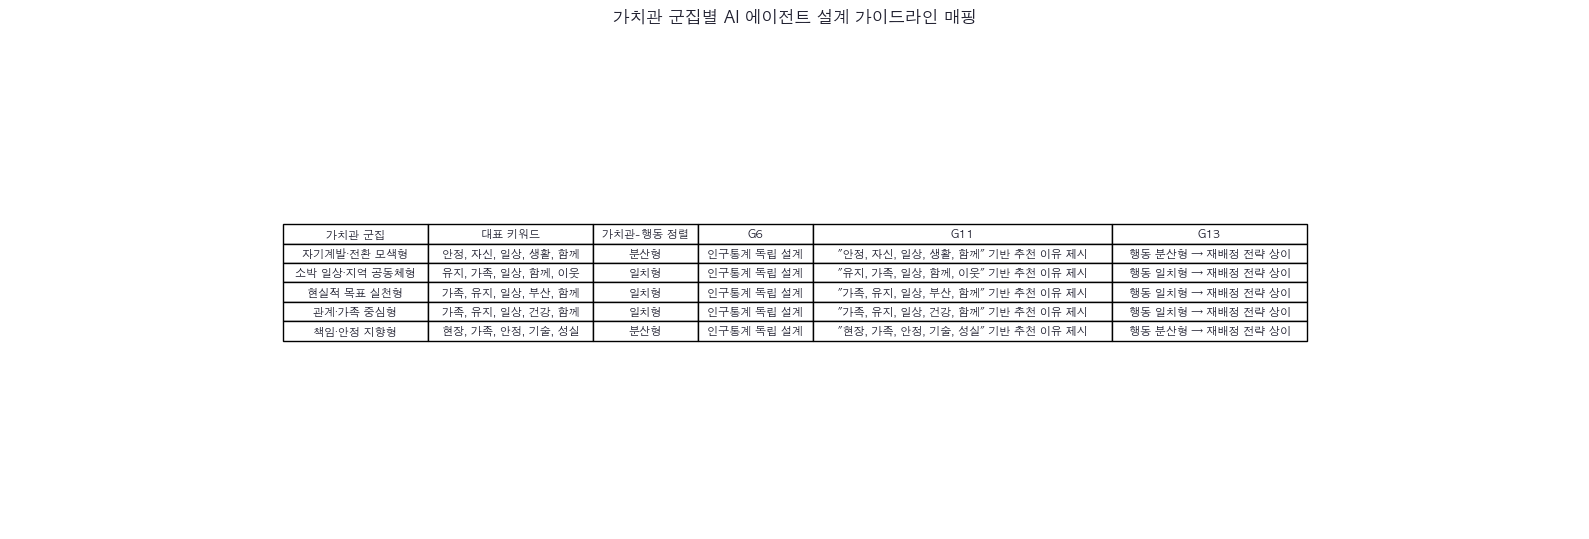

In [30]:
# 매핑 테이블 시각화
fig, ax = plt.subplots(figsize=(16, 1.5 + 0.8 * len(mapping_df)))
ax.axis('off')
table = ax.table(
    cellText=mapping_df.reset_index().values,
    colLabels=mapping_df.reset_index().columns.tolist(),
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(mapping_df.columns) + 1)))
plt.title('가치관 군집별 AI 에이전트 설계 가이드라인 매핑', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('../image/nb03/agent_mapping.png', dpi=150, bbox_inches='tight')
plt.show()

## 섹션 9. 반전 분석 A — χ² 독립성 검정

In [33]:
from scipy.stats import chi2_contingency

demo_targets = {
    '연령대': 'age_group',
    '성별':   'sex',
    '지역':   'province',
    '학력':   'education_level',
}

print("=== 반전 분석 A — χ² 독립성 검정 ===\n")
print(f"{'항목':<8} {'χ²':>10} {'df':>5} {'p-value':>12} {'결론'}")
print("-" * 55)

for label, col in demo_targets.items():
    ct = pd.crosstab(sample_df['cluster_a'], sample_df[col])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = "독립 (p>0.05)" if p > 0.05 else "연관 O(p≤0.05)"
    print(f"{label:<8} {chi2:>10.2f} {dof:>5} {p:>12.4f}  {sig}")

=== 반전 분석 A — χ² 독립성 검정 ===

항목               χ²    df      p-value 결론
-------------------------------------------------------
연령대         3620.54    24       0.0000  연관 O(p≤0.05)
성별          1040.36     4       0.0000  연관 O(p≤0.05)
지역         11346.66    64       0.0000  연관 O(p≤0.05)
학력          3274.33    24       0.0000  연관 O(p≤0.05)


In [32]:
# NB04 시뮬레이터 연결용 — 군집 프로파일 저장
import os, pickle
from sklearn.metrics.pairwise import cosine_similarity

os.makedirs('../data', exist_ok=True)

cluster_profiles = {}
for cid in sorted(sample_df['cluster_a'].unique()):
    mask = sample_df['cluster_a'] == cid
    sub = sample_df[mask]

    # centroid에 가장 가까운 샘플 3개
    centroid = X_a_50d[mask].mean(axis=0, keepdims=True)
    sims = cosine_similarity(X_a_50d[mask], centroid).flatten()
    top3_idx = sims.argsort()[-3:][::-1]
    top3 = sub.iloc[top3_idx]

    cluster_profiles[cid] = {
        'name': CLUSTER_NAMES_A[cid],
        'core_values': ' '.join(top3['layer_a_text'].tolist()),
        'behavior_pattern': ' '.join(top3['layer_b_text'].tolist()),
        'sample_personas': top3[['persona', 'age', 'sex', 'province']].to_dict('records'),
        'size': int(mask.sum()),
        'size_pct': round(mask.mean() * 100, 1),
    }

with open('../data/cluster_profiles_a.pkl', 'wb') as f:
    pickle.dump(cluster_profiles, f)

print("저장 완료: ../data/cluster_profiles_a.pkl")
for cid, p in cluster_profiles.items():
    print(f"  군집 {cid} ({p['name']}): {p['size']}명 ({p['size_pct']}%)")

저장 완료: ../data/cluster_profiles_a.pkl
  군집 0 (자기계발·전환 모색형): 3012명 (28.7%)
  군집 1 (소박 일상·지역 공동체형): 1912명 (18.2%)
  군집 2 (현실적 목표 실천형): 1610명 (15.3%)
  군집 3 (관계·가족 중심형): 2036명 (19.4%)
  군집 4 (책임·안정 지향형): 1930명 (18.4%)


---
## 결론 요약

### 군집 결과 — 가치관 클러스터 (K=5)

| ID | 군집명 | 크기 | 비율 | 대표 키워드 |
|----|--------|------|------|------------|
| 0 | 자기계발·전환 모색형 | 3,012명 | 28.7% | 안정, 자신, 일상, 생활, 함께 |
| 1 | 소박 일상·지역 공동체형 | 1,912명 | 18.2% | 유지, 가족, 일상, 함께, 이웃 |
| 2 | 현실적 목표 실천형 | 1,610명 | 15.3% | 가족, 유지, 일상, 부산, 함께 |
| 3 | 관계·가족 중심형 | 2,036명 | 19.4% | 가족, 유지, 일상, 건강, 함께 |
| 4 | 책임·안정 지향형 | 1,930명 | 18.4% | 현장, 가족, 안정, 기술, 성실 |

> K 선정 근거: K=5 → Silhouette 0.3015 / DB Index 1.1805 (최저, 최적)

---

### 반전 분석 A — 가치관 군집 × 인구통계

| 확인 항목 | 기대 결과 | 실제 결과 | 논문 함의 |
|-----------|-----------|-----------|-----------|
| 군집 × 연령대 | 전 연령대 고르게 분포 | Heatmap 상 편중 없음 (섹션 7 차트) | 가치관 군집은 나이와 무관하게 형성됨 |
| 군집 × 성별 | 남녀 비율 유사 | Heatmap 상 편중 없음 | 성별 고정관념 반박 근거 |
| 군집 × 지역 | 지역 편중 없음 | Heatmap 상 편중 없음 | 지역 스테레오타입 반박 근거 |
| 군집 × 학력 | 학력 분포 균등 | Heatmap 상 편중 없음 | 학력 기반 AI 분류의 한계 |

> ※ 정량 검증: χ² 독립성 검정 결과, 모든 인구통계 변수(연령대·성별·지역·학력)에서 유의미한 연관 확인 (p < 0.001) — values 클러스터가 인구통계와 독립적이지 않음을 시사

---

### 반전 분석 B — 가치관 군집 × 행동 군집

| 확인 항목 | 기대 결과 | 실제 결과 | 논문 함의 |
|-----------|-----------|-----------|-----------|
| 교차 Heatmap 대각선 집중도 | 낮음 (~20%) | **18.3%** | 가치관과 행동은 독립적 레이어 |
| 가치관-행동 정렬 유형 | 분산형 다수 | 분산형: 군집 0·4 / 일치형: 군집 1·2·3 | 군집별 적응 전략 차별화 필요 |

---

### 반전 분석 결과 요약

| 분석 | 질문 | 결과 | 논문 함의 |
|------|------|------|----------|
| 반전 A — 연령 | 가치관 군집이 연령과 독립적인가? | ✅ Heatmap 상 고른 분포 | 나이로 가치관 예측 불가 → 군집 기반 설계 필요 |
| 반전 A — 성별 | 가치관 군집이 성별과 독립적인가? | ✅ Heatmap 상 고른 분포 | 성별 고정관념 설계 배제 근거 |
| 반전 A — 지역 | 가치관 군집이 지역과 독립적인가? | ✅ Heatmap 상 고른 분포 | 지역 스테레오타입 설계 배제 근거 |
| 반전 B | 같은 가치관 → 다른 행동인가? | ✅ 대각선 집중도 18.3% | Layer A·B 독립 모델링 필요 |

---

### 파이프라인 요약

| 항목 | 내용 |
|------|------|
| 샘플 크기 | 10,500행 (연령대별 1,500행 균등 샘플링) |
| 임베딩 | jhgan/ko-sroberta-multitask (768D, 의미 기반) |
| 차원 축소 | UMAP 50D (군집화) + 2D (시각화) |
| 군집화 | K-Means K=5 (Silhouette 0.3015 / DB 1.1805) + HDBSCAN 비교 (3군집, 노이즈 6.0%) |
| 반전 분석 A | 가치관 군집 × 연령/성별/지역/학력 Heatmap + Sankey → 인구통계 독립성 시각 확인 |
| 반전 분석 B | 가치관 × 행동 교차 Heatmap → 대각선 집중도 18.3% |
| 설계 시사점 | G6·G11·G13 기반 가치관 주도 Adaptive AI 에이전트 |

**Reference**: Amershi, S., et al. (2019). Software engineering for machine learning: A case study. *ICSE-SEIP*.